# **GA Meal Planner**

This notebook tests the `GAMealPlanner`, implementing a genetic algorithm to optimise meal plans based on user preferences and nutritional requirements by using a fitness function.

In [1]:
import json
import os
import sys

sys.path.insert(0, os.path.abspath(".."))

from datetime import datetime, timedelta
from random import randint, random, seed

import matplotlib.pyplot as plt
import seaborn as sns

from engines import (
    GAMealPlanner,
    filter_and_add_recipes,
    get_pantry_ingredient,
    load_all_ingredients,
    make_preferences,
    parse_recipes,
)
from models import (
    MealPlanningEnvironment,
    Pantry,
)

## Environment Setup

In [2]:
seed(1)

In [3]:
preferences = make_preferences()

In [4]:
all_ingredients = load_all_ingredients("../recipe_extraction/supplemented_structured_ingredients.json")

In [5]:
CURRENT_DATE = datetime.now()

In [6]:
pantry_ingredient_name_by_quantity = {
    "chicken breast": 800,
    "broccoli": 1500,
    "rice": 1000,
}

In [7]:
pantry_ingredients = [
    get_pantry_ingredient(name, CURRENT_DATE + timedelta(days=randint(1, 7)), all_ingredients)
    for name in pantry_ingredient_name_by_quantity.keys()
]

In [8]:
pantry_ingredient_by_quantity = dict(zip(pantry_ingredients, pantry_ingredient_name_by_quantity.values()))

In [9]:
pantry = Pantry()

for pantry_ingredient, quantity in pantry_ingredient_by_quantity.items():
    pantry.add(
        pantry_ingredient,
        quantity,
    )

In [10]:
pantry.print()

---
Quantity: 800 g
Ingredient: chicken breast
	Estimated Expiration Date: 2026-05-26
	Nutritional Information:
		Calories: 125.0 kcal
		Carbohydrates: 1.79 g
		Sugar: 0.0 g
		Protein: 16.07 g
		Fat: 5.36 g
		Saturated Fat: 1.79 g
		Fiber: 1.8 g
		Sodium: 571.0 mg
		Gluten Free: Yes
		Lactose Free: Yes
		Vegetarian: No
		Vegan: No
---
---
Quantity: 1500 g
Ingredient: broccoli
	Estimated Expiration Date: 2026-05-29
	Nutritional Information:
		Calories: 31.0 kcal
		Carbohydrates: 6.27 g
		Sugar: 1.4 g
		Protein: 2.57 g
		Fat: 0.34 g
		Saturated Fat: 0.039 g
		Fiber: 2.4 g
		Sodium: 36.0 mg
		Gluten Free: Yes
		Lactose Free: Yes
		Vegetarian: Yes
		Vegan: Yes
---
---
Quantity: 1000 g
Ingredient: rice
	Estimated Expiration Date: 2026-05-31
	Nutritional Information:
		Calories: 356.0 kcal
		Carbohydrates: 80.0 g
		Sugar: 0.0 g
		Protein: 6.67 g
		Fat: 0.0 g
		Saturated Fat: 0.0 g
		Fiber: 2.2 g
		Sodium: 0.0 mg
		Gluten Free: Yes
		Lactose Free: Yes
		Vegetarian: Yes
		Vegan: Yes
---


In [11]:
with open("../recipe_extraction/supplemented_structured_recipes.json", "r") as file:
    all_recipes = json.load(file)

In [12]:
all_recipes = parse_recipes(all_recipes)

In [13]:
NUM_FILTERED_RECIPES = 100
NUM_EXTRA_RECIPES = 50

In [14]:
final_recipes = filter_and_add_recipes(
    all_recipes, [ingredient.name for ingredient in pantry_ingredients], NUM_FILTERED_RECIPES, NUM_EXTRA_RECIPES
)

In [16]:
print(f"Number of recipes before filtering: {len(all_recipes)}")
print(f"Number of recipes after filtering: {len(final_recipes)}")

Number of recipes before filtering: 19716
Number of recipes after filtering: 150


In [17]:
meal_planning_environment = MealPlanningEnvironment(
    recipes=final_recipes,
    pantry=pantry,
    preferences=preferences,
)

In [18]:
all_ingredient_names = []

for recipe in meal_planning_environment.recipes:
    for ingredient_name in recipe.ingredients.keys():
        all_ingredient_names.append(ingredient_name)

In [19]:
all_ingredient_costs = {}

for ingredient_name in sorted(set(all_ingredient_names)):
    all_ingredient_costs[ingredient_name] = random()

In [20]:
meal_planning_environment.ingredient_costs = all_ingredient_costs
meal_planning_environment._check_ingredient_costs()

## Running the GA Meal Planner

In [21]:
planner = GAMealPlanner(meal_planning_environment)

In [22]:
NUM_GENERATIONS = 500
NUM_PARENTS_MATING = 20
POPULATION_SIZE = 100
NUM_DAYS = 7
NUM_MEALS_PER_DAY = 3
GENERATION_PRINT_INTERVAL = 50
SEED = 1

In [23]:
best_meal_plan, best_fitness_score = planner.generate_meal_plan(
    num_days=NUM_DAYS,
    meals_per_day=NUM_MEALS_PER_DAY,
    num_generations=NUM_GENERATIONS,
    num_parents_mating=NUM_PARENTS_MATING,
    population_size=POPULATION_SIZE,
    generation_print_interval=GENERATION_PRINT_INTERVAL,
    seed=SEED,
)

Generation 50, Best Fitness: -0.13
Generation 100, Best Fitness: -0.10
Generation 150, Best Fitness: -0.08
Generation 200, Best Fitness: -0.05
Generation 250, Best Fitness: -0.03
Generation 300, Best Fitness: -0.02
Generation 350, Best Fitness: -0.01
Generation 400, Best Fitness: -0.01
Generation 450, Best Fitness: -0.01
Generation 500, Best Fitness: -0.01


### *GA Meal Plan Results*

In [24]:
print(f"Best fitness score: {best_fitness_score:.2f}")

Best fitness score: -0.01


In [25]:
sns.set_theme("notebook")
colours = sns.color_palette("husl", NUM_GENERATIONS + 1)

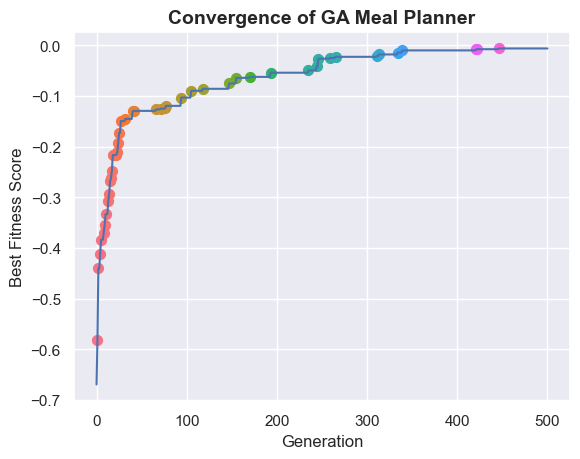

In [26]:
convergence_values = planner.ga_instance.best_solutions_fitness

plt.plot(convergence_values)

for i in range(1, len(convergence_values)):
    if convergence_values[i] != convergence_values[i - 1]:
        plt.scatter(i, convergence_values[i], color=colours[i], s=50)

plt.title("Convergence of GA Meal Planner", fontsize=14, fontweight="bold")
plt.xlabel("Generation")
plt.ylabel("Best Fitness Score")
plt.show()

In [27]:
pantry_consumption_df = planner.get_pantry_consumption()
pantry_consumption_df

,Ingredient,Available,Consumed,Unused,Expires in
0,chicken breast,800,226.796185,573.203815,1d
1,broccoli,1500,1500.000000,0.000000,4d
2,rice,1000,629.071769,370.928231,6d


In [28]:
meal_plan_df = planner.get_meal_plan_recipes()
meal_plan_df

,Meal 1,Meal 2,Meal 3
Day 1,Roasted Broccoli Florets with Toasted Breadcru...,Chicken Tortilla Soup,Chicken Tortilla Soup
Day 2,Asian-Style Shrimp and Pineapple Fried Rice,Frittata with Fennel-Spiced Pork and Asparagus,Harissa Shrimp And Summer Vegetable Sauté
Day 3,"Broccoli and Cauliflower with Lemon, Mustard a...",Roast Turkey with Pesto-Rice Stuffing,"Beef, Mushroom, and Broccoli Stir-Fry"
Day 4,Broccoli with Toasted Garlic Crumbs,Roasted Broccoli Florets with Toasted Breadcru...,Okra Beignets with Cilantro Sour Cream Sauce
Day 5,Yukari Shiso Salt Yaki Onigiri,Four-Cheese Manicotti,"Fried Rice with Ham, Egg, and Scallions"
Day 6,"Fried Rice with Ham, Egg, and Scallions",Harissa Shrimp And Summer Vegetable Sauté,Asian-Style Shrimp and Pineapple Fried Rice
Day 7,Ginger-Garlic Shrimp,Peanut Noodles with Gingered Vegetables and Tofu,Roast Turkey with Pesto-Rice Stuffing


In [29]:
shopping_list_df, num_ingredients, total_cost = planner.get_shopping_list()

print(f"Total ingredients needed to purchase: {num_ingredients}")
print(f"Total cost: €{total_cost:.2f}")

shopping_list_df

Total ingredients needed to purchase: 107
Total cost: €18.73


,Ingredient,Quantity to Buy (g),Cost (€)
0,Bacon slices,7.4,0.03
1,Chinese Peanut Sauce,3.0,0.02
2,Crushed tortilla chips,50.0,0.17
3,Dijon mustard,4.2,0.03
4,Olive oil,19.9,0.02
...,...,...,...
103,whole peeled tomatoes,12.5,0.04
104,yakari shiso salt,1.4,0.01
105,yellow crookneck squash,16.7,0.12
106,zucchini,9.8,0.06


In [30]:
daily_nutrition_df = planner.get_daily_nutrition()
daily_nutrition_df

,Calories,Protein,Δ Calories and Target Calories,Δ Protein and Target Protein
Day 1,1053.4 kcal,56.6 g,-946.6 kcal,6.6 g
Day 2,1612.6 kcal,55.8 g,-387.4 kcal,5.8 g
Day 3,2252.6 kcal,49.8 g,252.6 kcal,-0.2 g
Day 4,2145.4 kcal,73.7 g,145.4 kcal,23.7 g
Day 5,1312.7 kcal,50.1 g,-687.3 kcal,0.1 g
Day 6,1263.7 kcal,51.4 g,-736.3 kcal,1.4 g
Day 7,2098.8 kcal,48.6 g,98.8 kcal,-1.4 g
